# xG Project -- EDA (Exploratory Data Analysis)

Shots extracted from StatsBomb Open Data.
Scope: all male professional competitions, penalties and own goals excluded, free kicks included.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = Path("../data/shots_raw.parquet")
df = pd.read_parquet(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (65822, 18)


,match_id,competition,season,minute,second,player,team,x,y,shot_outcome,shot_type,shot_body_part,shot_technique,play_pattern,under_pressure,shot_freeze_frame,statsbomb_xg,is_goal
0,3895286,1. Bundesliga,2023/2024,5,24,Jonas Hofmann,Bayer Leverkusen,93.5,38.9,Blocked,Open Play,Right Foot,Normal,Regular Play,False,"[{""location"": [100.3, 38.6], ""player"": {""id"": ...",0.040825,0
1,3895286,1. Bundesliga,2023/2024,10,35,Granit Xhaka,Bayer Leverkusen,100.4,37.0,Saved,Open Play,Left Foot,Normal,From Throw In,False,"[{""location"": [104.3, 26.2], ""player"": {""id"": ...",0.120054,0
2,3895286,1. Bundesliga,2023/2024,16,55,Granit Xhaka,Bayer Leverkusen,90.7,39.2,Blocked,Open Play,Left Foot,Normal,Regular Play,False,"[{""location"": [97.1, 37.5], ""player"": {""id"": 2...",0.026811,0
3,3895286,1. Bundesliga,2023/2024,17,29,Florian Wirtz,Bayer Leverkusen,98.0,30.3,Off T,Open Play,Right Foot,Normal,Regular Play,False,"[{""location"": [106.2, 33.6], ""player"": {""id"": ...",0.038797,0
4,3895286,1. Bundesliga,2023/2024,19,13,Jonas Hofmann,Bayer Leverkusen,109.4,58.6,Blocked,Open Play,Right Foot,Normal,From Free Kick,False,"[{""location"": [111.3, 45.8], ""player"": {""id"": ...",0.009383,0


## 1. Basic Statistics

In [2]:
print("=== Target Distribution ===")
print(df["is_goal"].value_counts())
print(f"\nGoal rate: {df['is_goal'].mean():.4f} ({df['is_goal'].mean()*100:.1f}%)")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")

=== Target Distribution ===
is_goal
0    59155
1     6667
Name: count, dtype: int64

Goal rate: 0.1013 (10.1%)

Null counts:
match_id             0
competition          0
season               0
minute               0
second               0
player               0
team                 0
x                    0
y                    0
shot_outcome         0
shot_type            0
shot_body_part       0
shot_technique       0
play_pattern         0
under_pressure       0
shot_freeze_frame    0
statsbomb_xg         0
is_goal              0
dtype: int64

Data types:
match_id               int64
competition              str
season                   str
minute                 int64
second                 int64
player                   str
team                     str
x                    float64
y                    float64
shot_outcome             str
shot_type                str
shot_body_part           str
shot_technique           str
play_pattern             str
under_pressure          bool


In [3]:
print("=== Shots per Competition ===")
comp_stats = df.groupby("competition").agg(
    shots=("is_goal", "count"),
    goals=("is_goal", "sum"),
    goal_rate=("is_goal", "mean"),
).sort_values("shots", ascending=False)
comp_stats["goal_rate"] = comp_stats["goal_rate"].map("{:.3f}".format)
print(comp_stats.to_string())

=== Shots per Competition ===
                        shots  goals goal_rate
competition                                   
La Liga                 20936   2462     0.118
Premier League          10735    998     0.093
Ligue 1                 10235   1027     0.100
Serie A                  9912    862     0.087
FIFA World Cup           3770    350     0.093
Indian Super league      3053    315     0.103
UEFA Euro                2538    220     0.087
1. Bundesliga            1738    184     0.106
African Cup of Nations   1162     98     0.084
Copa America              741     63     0.085
Champions League          561     51     0.091
Major League Soccer       146     12     0.082
UEFA Europa League         87      6     0.069
Copa del Rey               73      7     0.096
Liga Profesional           56      6     0.107
North American League      50      3     0.060
FIFA U20 World Cup         29      3     0.103


## 2. Class Imbalance

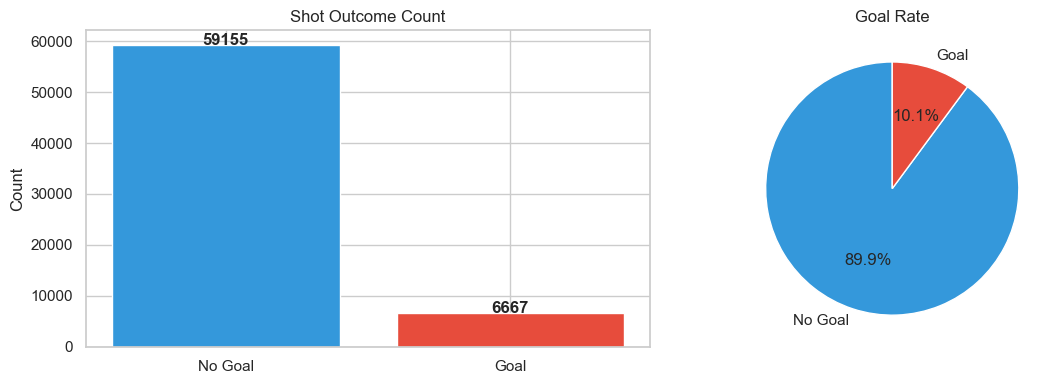

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["is_goal"].value_counts()
labels = ["No Goal", "Goal"]
colors = ["#3498db", "#e74c3c"]

axes[0].bar(labels, counts.values, color=colors)
axes[0].set_title("Shot Outcome Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Goal Rate")

plt.tight_layout()
plt.show()

## 3. Shot Location Heatmap

StatsBomb pitch coordinates: x = 0-120 (length), y = 0-80 (width). Goal is at x=120.

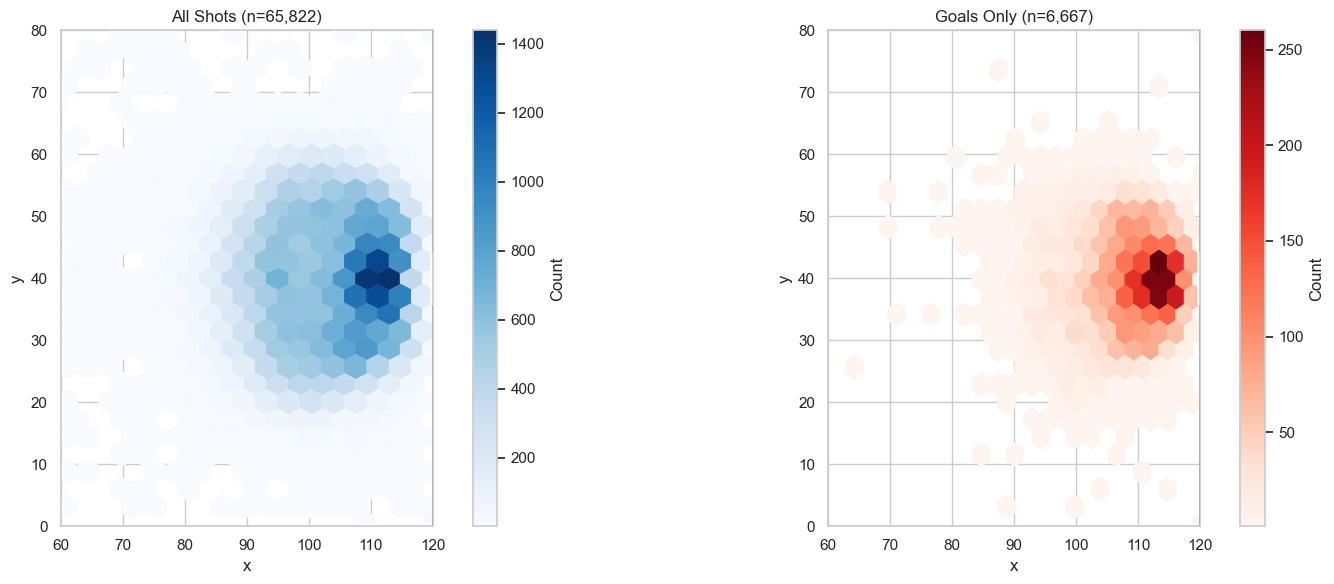

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

shot_data = df.dropna(subset=["x", "y"])

# All shots
axes[0].set_xlim(60, 120)
axes[0].set_ylim(0, 80)
axes[0].set_aspect("equal")
hb = axes[0].hexbin(shot_data["x"], shot_data["y"], gridsize=25, cmap="Blues", mincnt=1)
axes[0].set_title(f"All Shots (n={len(shot_data):,})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(hb, ax=axes[0], label="Count")

# Goal line for reference
axes[0].axvline(x=120, color="black", linewidth=2)
axes[0].plot([120, 120], [36, 44], color="white", linewidth=4)

# Goals only
goals = shot_data[shot_data["is_goal"] == 1]
axes[1].set_xlim(60, 120)
axes[1].set_ylim(0, 80)
axes[1].set_aspect("equal")
hb2 = axes[1].hexbin(goals["x"], goals["y"], gridsize=25, cmap="Reds", mincnt=1)
axes[1].set_title(f"Goals Only (n={len(goals):,})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(hb2, ax=axes[1], label="Count")

axes[1].axvline(x=120, color="black", linewidth=2)
axes[1].plot([120, 120], [36, 44], color="white", linewidth=4)

plt.tight_layout()
plt.show()

## 4. Goal Conversion Rate by Zone

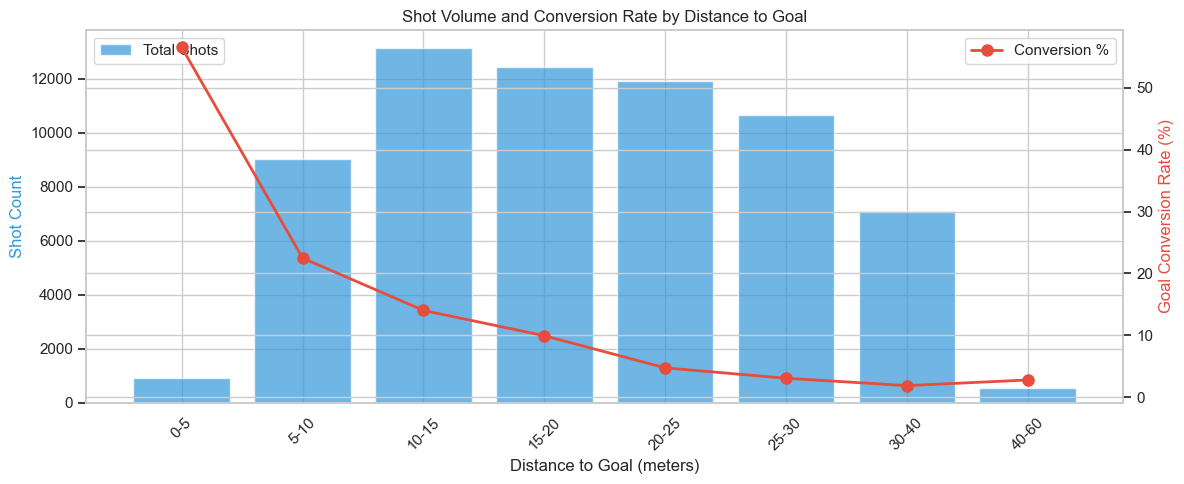

          shots  goals  conversion_rate
dist_bin                               
0-5         906    512         0.565121
5-10       9025   2029         0.224820
10-15     13135   1843         0.140312
15-20     12442   1238         0.099502
20-25     11915    567         0.047587
25-30     10655    328         0.030784
30-40      7086    134         0.018911
40-60       536     15         0.027985


In [6]:
import numpy as np

shot_data = df.dropna(subset=["x", "y"]).copy()

goal_center_x, goal_center_y = 120.0, 40.0
shot_data["distance"] = np.sqrt(
    (shot_data["x"] - goal_center_x) ** 2 + (shot_data["y"] - goal_center_y) ** 2
)

bins = [0, 5, 10, 15, 20, 25, 30, 40, 60]
labels = ["0-5", "5-10", "10-15", "15-20", "20-25", "25-30", "30-40", "40-60"]
shot_data["dist_bin"] = pd.cut(shot_data["distance"], bins=bins, labels=labels)

zone_stats = shot_data.groupby("dist_bin", observed=False).agg(
    shots=("is_goal", "count"),
    goals=("is_goal", "sum"),
    conversion_rate=("is_goal", "mean"),
)

fig, ax1 = plt.subplots(figsize=(12, 5))

color_bar = "#3498db"
color_line = "#e74c3c"

x_pos = range(len(zone_stats))
ax1.bar(x_pos, zone_stats["shots"], color=color_bar, alpha=0.7, label="Total Shots")
ax1.set_xlabel("Distance to Goal (meters)")
ax1.set_ylabel("Shot Count", color=color_bar)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, rotation=45)

ax2 = ax1.twinx()
ax2.plot(x_pos, zone_stats["conversion_rate"] * 100, color=color_line,
         marker="o", linewidth=2, markersize=8, label="Conversion %")
ax2.set_ylabel("Goal Conversion Rate (%)", color=color_line)

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Shot Volume and Conversion Rate by Distance to Goal")
plt.tight_layout()
plt.show()

print(zone_stats.to_string())

## 5. Categorical Feature Distributions

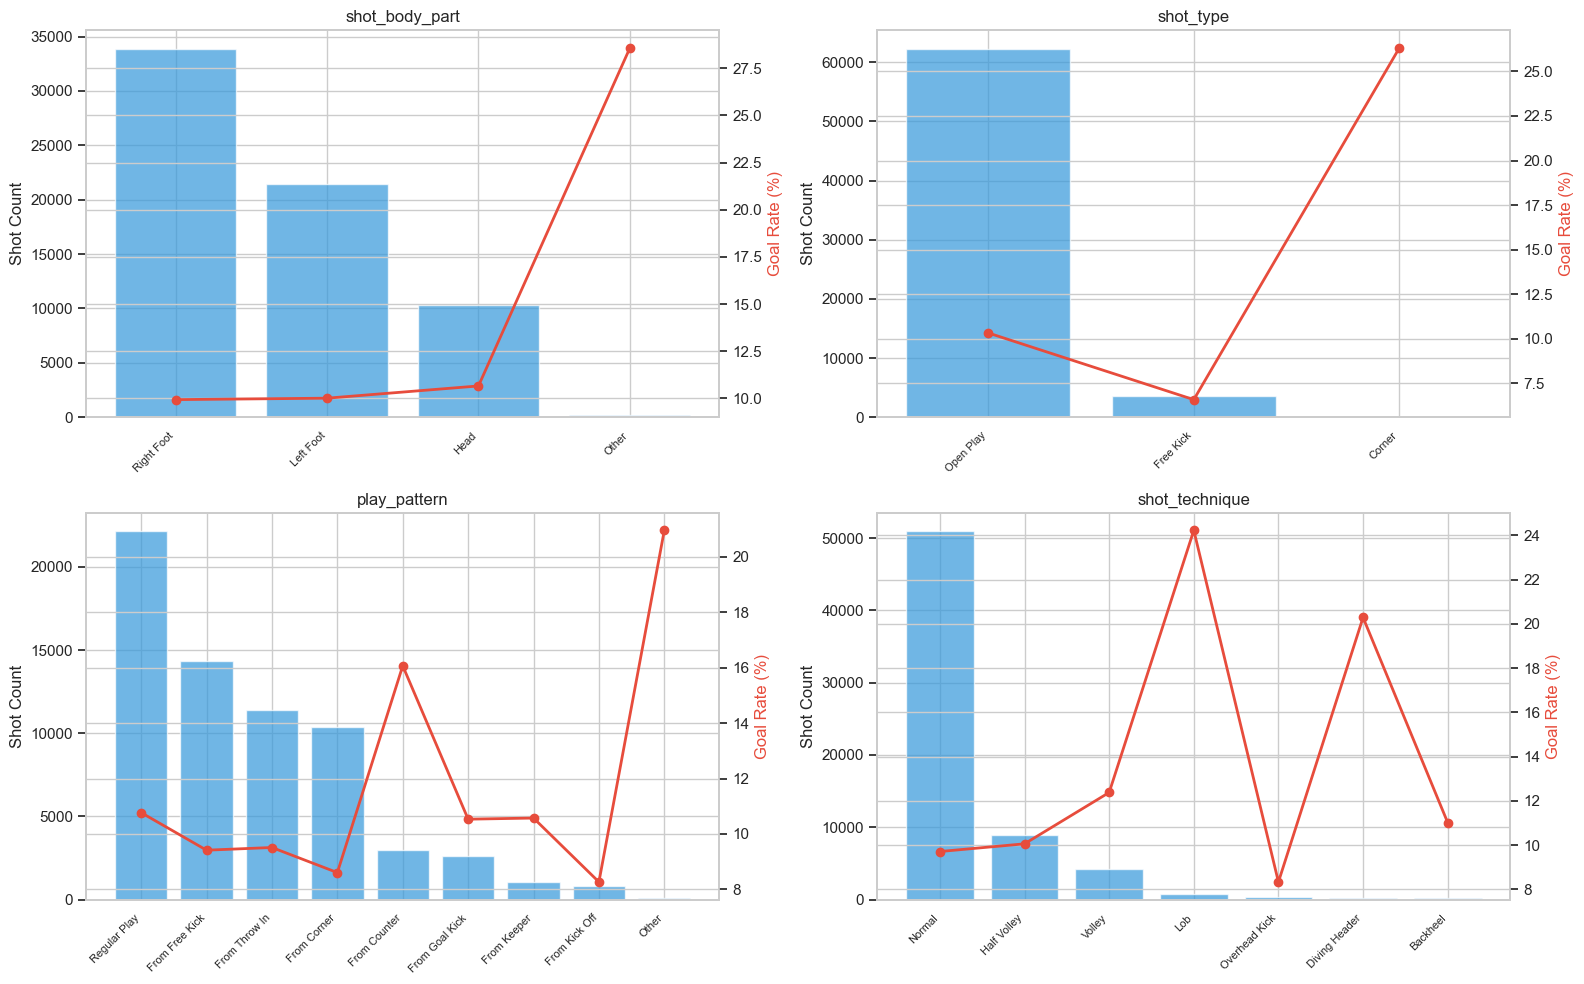

In [7]:
cat_cols = ["shot_body_part", "shot_type", "play_pattern", "shot_technique"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    col_stats = df.groupby(col).agg(
        shots=("is_goal", "count"),
        goal_rate=("is_goal", "mean"),
    ).sort_values("shots", ascending=False)

    ax1 = axes[i]
    x_pos = range(len(col_stats))
    ax1.bar(x_pos, col_stats["shots"], color="#3498db", alpha=0.7)
    ax1.set_ylabel("Shot Count")
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(col_stats.index, rotation=45, ha="right", fontsize=8)
    ax1.set_title(col)

    ax2 = ax1.twinx()
    ax2.plot(x_pos, col_stats["goal_rate"] * 100, color="#e74c3c",
             marker="o", linewidth=2)
    ax2.set_ylabel("Goal Rate (%)", color="#e74c3c")

plt.tight_layout()
plt.show()

## 6. Under Pressure Analysis

                shots  goals  goal_rate
under_pressure                         
False           50356   5229   0.103841
True            15466   1438   0.092978


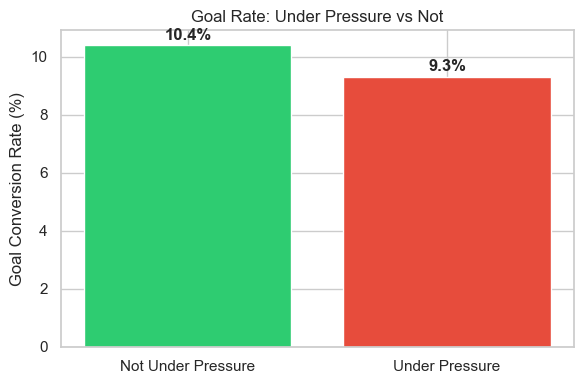

In [8]:
pressure_stats = df.groupby("under_pressure").agg(
    shots=("is_goal", "count"),
    goals=("is_goal", "sum"),
    goal_rate=("is_goal", "mean"),
)
print(pressure_stats)

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Not Under Pressure", "Under Pressure"]
rates = pressure_stats["goal_rate"].values * 100
ax.bar(labels, rates, color=["#2ecc71", "#e74c3c"])
ax.set_ylabel("Goal Conversion Rate (%)")
ax.set_title("Goal Rate: Under Pressure vs Not")
for i, v in enumerate(rates):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. StatsBomb xG Distribution (Benchmark Reference)

This is NOT a feature -- only used for comparing our model's output later.

C:\Users\Talha\AppData\Local\Temp\claude\ipykernel_28816\298509067.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


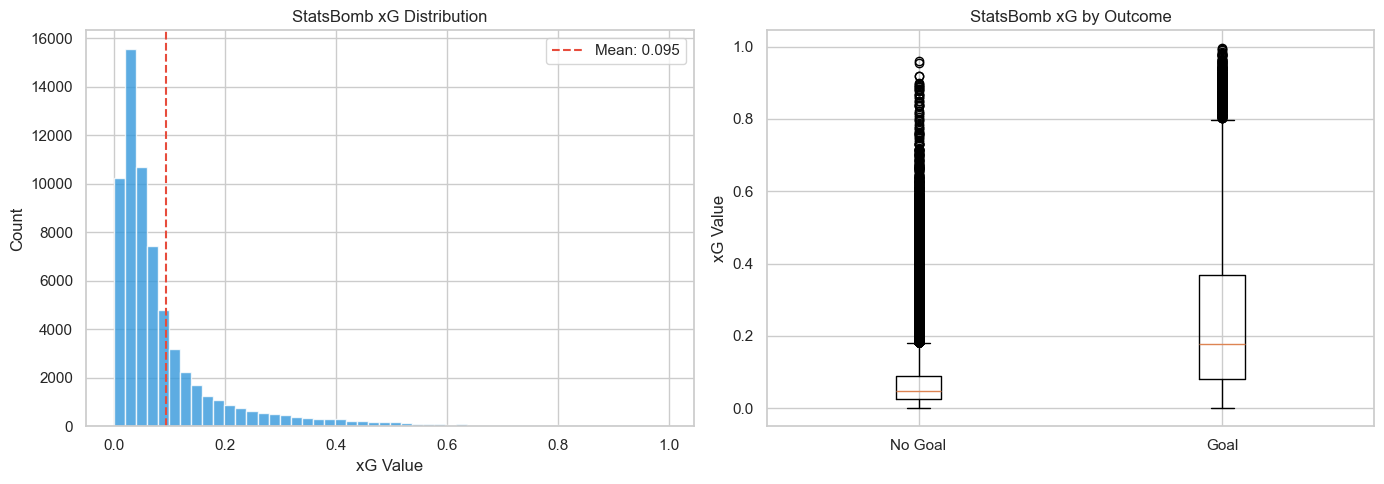

StatsBomb xG stats:
count    65822.000000
mean         0.094548
std          0.124041
min          0.000180
25%          0.027037
50%          0.052421
75%          0.102976
max          0.995122
Name: statsbomb_xg, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xg_data = df["statsbomb_xg"].dropna()

axes[0].hist(xg_data, bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].set_title("StatsBomb xG Distribution")
axes[0].set_xlabel("xG Value")
axes[0].set_ylabel("Count")
axes[0].axvline(x=xg_data.mean(), color="#e74c3c", linestyle="--",
                label=f"Mean: {xg_data.mean():.3f}")
axes[0].legend()

# xG by outcome
xg_by_outcome = df.dropna(subset=["statsbomb_xg"])
axes[1].boxplot(
    [xg_by_outcome[xg_by_outcome["is_goal"] == 0]["statsbomb_xg"],
     xg_by_outcome[xg_by_outcome["is_goal"] == 1]["statsbomb_xg"]],
    labels=["No Goal", "Goal"],
)
axes[1].set_title("StatsBomb xG by Outcome")
axes[1].set_ylabel("xG Value")

plt.tight_layout()
plt.show()

print(f"StatsBomb xG stats:\n{xg_data.describe()}")

## 8. Summary

Key observations:
- **Total shots:** 65,822 from 2,651 matches across 17 competitions
- **Goal rate:** 10.1% (6,667 goals) -- class imbalance confirmed as expected
- **No null values** in any column -- data is clean
- **Distance is inversely correlated with goal probability:** 56.5% at 0-5m, dropping to 1.9% at 30-40m (strong sanity check)
- **Under pressure** reduces goal rate slightly (9.3% vs 10.4%)
- **StatsBomb xG** distribution is right-skewed (mean 0.095, median 0.052) -- most shots are low quality
- **La Liga** dominates the dataset (20,936 shots), followed by PL (10,735) and Ligue 1 (10,235)
- **Free kicks** included: 3,524 shots (shot_type), identifiable via play_pattern